# <font color='blue'><div style="text-align: center">Pandas</font>

### <font color='blue'> The pandas data-frame </font>
* 넘파이는 다차원 변수를 배열형태로 저장하고 효과적으로 다룰 수 있다.
* 판다스는 엑셀형태의 쉬트와 같이 통계자료를 저장하는 라이브러리다.
* 이 세상의 대부분의 자료는 엑셀 쉬트처럼 생겼는데 행렬 원소로 보는 것보다 기존 통계소프트웨어처럼 처리하는 방식이다.
* 통계처리는 대부분 판다스로 끝난다. 하지만, 판다스로 처리가 힘든 것은 넘파이나 기존 파이썬 언어의 도움을 받아 처리가 가능하다.
* 판다스는 Series객체의 집합으로 이루어져 있어 DataFrame <-> Series <-> numpy <-> List 로 자유자재로 형을 변환할 수 있다.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 아래는 이미 알고 있는 리스트다.
nameList = ['John', 'Matt', 'Sara', 'Jim', 'Ashley']
ids = [ 23, 34, 83, 86, 12]
balance = [10.2, 84.3, 72.9, 27.1, 223.1]


### <font color='blue'> 리스트로 데이터프레임 만들기 </font>  

In [ ]:
# 아래는 위의 리스트를 딕셔너리로 묶어 데이터프레임으로 변환하는 예다.

dic = {'ids': ids, 'names': nameList, 'bal':balance}

users = pd.DataFrame(dic)
print (users)

   ids   names    bal
0   23    John   10.2
1   34    Matt   84.3
2   83    Sara   72.9
3   86     Jim   27.1
4   12  Ashley  223.1


In [ ]:
# 데이터프레임에서 시리즈만 추출하는 예제임

print(users['ids'])
print(users.ids)


0    23
1    34
2    83
3    86
4    12
Name: ids, dtype: int64
0    23
1    34
2    83
3    86
4    12
Name: ids, dtype: int64


In [ ]:
# 시리즈를 생성할 수도 있다.

s = pd.Series([10,20,30,40,50], index=[0,1,2,3,4])
s

,0
0,10
1,20
2,30
3,40
4,50


In [ ]:
# 시리즈를 데이터 프레임에 추가해 보자.
users['s'] = s
users

,ids,names,bal,s
0,23,John,10.2,10
1,34,Matt,84.3,20
2,83,Sara,72.9,30
3,86,Jim,27.1,40
4,12,Ashley,223.1,50


In [ ]:
# 레코드를 추가해 보자.
users.index = users.index + 1  # shifting index
users.loc[6] = [13, 'Paul', 24.7, 60]  # adding a row
users = users.sort_index()  # sorting by index
users

,ids,names,bal,s
1,23,John,10.2,10
2,34,Matt,84.3,20
3,83,Sara,72.9,30
4,86,Jim,27.1,40
5,12,Ashley,223.1,50
6,13,Paul,24.7,60


### <font color='blue'> CSV 파일로 데이터프레임 만들기 </font>  

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ML

 1_빅데이터_스몰데이터.pdf     Galton.ipynb		        SVM_basic.ipynb
 2_kNN.pdf		       GBM.ipynb		        SVM_iris_digit.ipynb
'3_Naive Bayes.pdf'	       kNN.ipynb		        SVM_kernel.ipynb
 4_Regression.pdf	       Mnist_AE_CNN_TF2.ipynb	        t-Test_bodyFat.ipynb
'5_Decision Tree.pdf'	       Mnist_AE_TF2.ipynb	        Untitled0.ipynb
 6_SVM.pdf		       Mnist_CNN_TF2.ipynb	        Untitled1.ipynb
'7_Neural Network.pdf'	       Mnist_DNN_Model_Save_TF2.ipynb   Untitled2.ipynb
'8_Deep Learning.pdf'	       Mnist_T-SNE.ipynb	        xor1.ipynb
'9_k-Means Clustering.pdf'     Numpy.ipynb		        XOR_DNN_TF2.ipynb
 AllPossibleRegression.ipynb   Over_Under.ipynb		        xor.ipynb
 ANOVA.ipynb		       Pandas.ipynb		        XOR_NN_TF2.ipynb
 chisq.ipynb		       perceptron.ipynb		        가설검정론.pdf
 Clustering.ipynb	       Pima_diabetes.ipynb	       '기초통계학 강의노트.pdf'
 convexity.ipynb	      'Ridge_Lasso Regression.ipynb'   '독버섯 판별.ipynb'
 data			       snsData_kMe

In [ ]:
filename = '/content/drive/MyDrive/ML/data/yob1880.csv'
names = pd.read_csv(filename, header = None)
names.columns = ['name','sex', 'vars']
print (names.head())

        name sex  vars
0       Mary   F  7065
1       Anna   F  2604
2       Emma   F  2003
3  Elizabeth   F  1939
4     Woodie   M  1234


### <font color='blue'> 엑셀 파일로 데이터프레임 만들기 </font>   

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/ML/data/yob1880.xlsx', header = None)
df.columns = ['name','sex', 'vars']
print (df.head())

        name  sex  vars
0       Mary    F  7065
1       Anna    F  2604
2       Emma    F  2003
3  Elizabeth    F  1939


### <font color='blue'> 데이터 프레임 나누기 </font>    

In [ ]:
# 행번호로 나누기

print (names.iloc[0])

name    Mary
sex        F
vars    7065
Name: 0, dtype: object


In [ ]:
subData = names.iloc[0:2]
subData

,name,sex,vars
0,Mary,F,7065
1,Anna,F,2604


In [ ]:
# 행과 열 번호로 나누기

names.iloc[:,[2,1,0]]

,vars,sex,name
0,7065,F,Mary
1,2604,F,Anna
2,2003,F,Emma
3,1939,F,Elizabeth
4,1234,M,Woodie
5,4567,M,Worthy
6,8901,M,Wright
7,2345,M,York
8,5567,M,Zachariah


In [ ]:
names['vars']

,vars
0,7065
1,2604
2,2003
3,1939
4,1234
5,4567
6,8901
7,2345
8,5567


In [ ]:
print(names)

        name sex  vars
0       Mary   F  7065
1       Anna   F  2604
2       Emma   F  2003
3  Elizabeth   F  1939
4     Woodie   M  1234
5     Worthy   M  4567
6     Wright   M  8901
7       York   M  2345
8  Zachariah   M  5567


In [ ]:
print(names.iloc[0:2,0:2])

   name sex
0  Mary   F
1  Anna   F


### <font color='blue'> 데이터프레임에서 Row 삭제 </font>     

In [ ]:
users = pd.DataFrame({'names': nameList, 'bal':balance}, index=ids)
users

,names,bal
23,John,10.2
34,Matt,84.3
83,Sara,72.9
86,Jim,27.1
12,Ashley,223.1


In [ ]:
new_users = users.copy()
new_users

,names,bal
23,John,10.2
34,Matt,84.3
83,Sara,72.9
86,Jim,27.1
12,Ashley,223.1


In [ ]:
new_users = new_users.drop(83)
new_users

,names,bal
23,John,10.2
34,Matt,84.3
86,Jim,27.1
12,Ashley,223.1


### <font color='blue'> 데이터프레임에서 column 삭제 </font>  

In [ ]:
new_users = users.drop('bal', axis=1)
new_users

,names
23,John
34,Matt
83,Sara
86,Jim
12,Ashley


### <font color='blue'> 데이터프레임 조건으로 drop하기 </font>  

In [ ]:
tmp = users.bal > 30.0
tmp

23    False
34     True
83     True
86    False
12     True
Name: bal, dtype: bool

### <font color='blue'> 데이터프레임 조건으로 Filter하기 </font>

In [ ]:
names[names.sex == 'F']

,name,sex,vars
0,Mary,F,7065
1,Anna,F,2604
2,Emma,F,2003
3,Elizabeth,F,1939


### <font color='blue'> 데이터프레임 소트 </font>   

In [ ]:
names.sort_values(["name"], ascending=[False])

,name,sex,vars
8,Zachariah,M,5567
7,York,M,2345
6,Wright,M,8901
5,Worthy,M,4567
4,Woodie,M,1234
0,Mary,F,7065
2,Emma,F,2003
3,Elizabeth,F,1939
1,Anna,F,2604


In [ ]:
fileName = '/content/drive/MyDrive/ML/data/hw1_data.csv'
data = pd.read_csv(fileName)
data

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
5,28.0,NaN,14.9,66,5,6
6,23.0,299.0,8.6,65,5,7
7,19.0,99.0,13.8,59,5,8
8,8.0,19.0,20.1,61,5,9
9,NaN,194.0,8.6,69,5,10


In [ ]:
data = data.dropna()

In [ ]:
data.describe()

,Ozone,Solar.R,Wind,Temp,Month,Day
count,7.000000,7.000000,7.000000,7.000000,7.0,7.000000
mean,22.428571,169.571429,11.714286,65.714286,5.0,4.857143
std,12.094863,106.829860,4.427350,5.648430,0.0,3.132016
min,8.000000,19.000000,7.400000,59.000000,5.0,1.000000
25%,15.000000,108.500000,8.300000,61.500000,5.0,2.500000
50%,19.000000,149.000000,11.500000,65.000000,5.0,4.000000
75%,29.500000,244.500000,13.200000,69.500000,5.0,7.500000
max,41.000000,313.000000,20.100000,74.000000,5.0,9.000000


In [29]:
# 연산하기 (화씨 -> 섭씨로)

data['Temp'] = (data['Temp'] - 32) / 1.8
data

<ipython-input-29-8d72227b1881>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Temp'] = (data['Temp'] - 32) / 1.8


,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,19.444444,5,1
1,36.0,118.0,8.0,22.222222,5,2
2,12.0,149.0,12.6,23.333333,5,3
3,18.0,313.0,11.5,16.666667,5,4
6,23.0,299.0,8.6,18.333333,5,7
7,19.0,99.0,13.8,15.000000,5,8
8,8.0,19.0,20.1,16.111111,5,9


In [31]:
data['Month'].value_counts()

,count
Month,
5,7


In [ ]:
data['Ozone'][data['Ozone'] < 15 ] = 15
data

d:\ProgramData\Anaconda3\lib\site-packages\ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  """Entry point for launching an IPython kernel.
d:\ProgramData\Anaconda3\lib\site-packages\pandas\core\generic.py:8682: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._update_inplace(new_data)
d:\ProgramData\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3296: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  exec(code_obj, self.user_global_ns, self.user_ns)


,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,19.444444,5,1
1,36.0,118.0,8.0,22.222222,5,2
2,15.0,149.0,12.6,23.333333,5,3
3,18.0,313.0,11.5,16.666667,5,4
6,23.0,299.0,8.6,18.333333,5,7
7,19.0,99.0,13.8,15.000000,5,8
8,15.0,19.0,20.1,16.111111,5,9


### <font color='blue'> 데이터프레임 Merge </font>  

In [38]:
import pandas as pd

df1 = pd.DataFrame({'id':['A','B','C'],'val1':[20,21,34]})
df2 = pd.DataFrame({'id':['C','D','E'],'val2':[55,44,11]})

df_inner = pd.merge(df1, df2, how='left', on='id')
df_inner

,id,val1,val2
0,A,20,NaN
1,B,21,NaN
2,C,34,55.0


In [ ]:
df_outer = pd.merge(df1, df2, how='outer', on='id')
df_outer

,id,val1,val2
0,A,20.0,NaN
1,B,21.0,NaN
2,C,34.0,55.0
3,D,NaN,44.0
4,E,NaN,11.0


In [ ]:
df_left = pd.merge(df1, df2, how='left', on='id')
df_left

,id,val1,val2
0,A,20,NaN
1,B,21,NaN
2,C,34,55.0


In [ ]:
df_right = pd.merge(df1, df2, how='right', on='id')
df_right

,id,val1,val2
0,C,34.0,55
1,D,NaN,44
2,E,NaN,11


### <font color='blue'> 데이터프레임 Concatenate </font>   

In [39]:
import pandas as pd

# create fake data
df1 = pd.DataFrame({'id':[6,7,8]})
df2 = pd.DataFrame({'id':[9,10,11]})

# glue the dataframes together
df = pd.concat([df1,df2])
df

,id
0,6
1,7
2,8
0,9
1,10
2,11


### <font color='blue'> 데이터프레임 저장관리 </font>

In [40]:
import pickle
df.to_pickle('df.pkl')
del df

In [41]:
df

NameError: name 'df' is not defined

In [42]:
f = open('df.pkl','rb')
df = pickle.load(f)
df

,id
0,6
1,7
2,8
0,9
1,10
2,11


### <font color='red'> 실습 #1: 판다스 부트캠프</font>

* PandasBootcamp.csv는 "date","num","num2","str","str2" 의 변수가 있는 자료다.
* 아래의 미션을 수행하시오.

In [43]:
# CSV 파일을 읽어 exData라는 데이터프레임으로 저장하세요.

filename = '/content/drive/MyDrive/ML/data/PandasBootcamp.csv'
exData = pd.read_csv(filename)
exData.head()

,date,num,num2,str,str2
0,2014-02-06,410,302.792029,girl,green
1,2014-02-07,457,697.175828,boy,yellow
2,2014-02-18,392,324.299927,boy,yellow
3,2014-03-05,685,25.789894,girl,blue
4,2014-03-31,991,919.491320,boy,red


In [44]:
# num의 최소, 최대, 평균값은 얼마입니까?
# str 과 str2에는 어떤 범주가 있고, 각 범주별 비율은 얼마인가요?

print(exData['num'].describe())
print()
print(exData['str'].value_counts())
print()
print(exData['str2'].value_counts())

count     50.000000
mean     504.460000
std      295.717682
min       11.000000
25%      309.750000
50%      455.500000
75%      723.500000
max      991.000000
Name: num, dtype: float64

str
boy     26
girl    24
Name: count, dtype: int64

str2
green     15
yellow    10
blue       9
red        9
purple     7
Name: count, dtype: int64


In [45]:
def value_proportion(pSeries):
    _tmp = pSeries.value_counts().to_dict()
    n = sum(list(_tmp.values()))
    retDic = {}
    for key, value in _tmp.items():
        retDic[key] = value / n
    return retDic

print(value_proportion(exData['str']))
print(value_proportion(exData['str2']))

{'boy': 0.52, 'girl': 0.48}
{'green': 0.3, 'yellow': 0.2, 'blue': 0.18, 'red': 0.18, 'purple': 0.14}


In [ ]:
# str 별 num의 합계를 구하시오
# str2별 num2의 평균을 구하시오.

groupby_str = exData.groupby('str')
print(groupby_str['num'].sum())

groupby_str2 = exData.groupby('str2')
print(groupby_str['num2'].mean())

str
boy     14104
girl    11119
Name: num, dtype: int64
str
boy     489.883667
girl    423.081643
Name: num2, dtype: float64


In [ ]:
# str과 str2의 교차표를 만들어보세요

pd.crosstab(exData.str, exData.str2, margins=True)

str2,blue,green,purple,red,yellow,All
str,,,,,,
boy,7,6,4,4,5,26
girl,2,9,3,5,5,24
All,9,15,7,9,10,50


### <font color='blue'> 유용한 시각화 예제 </font>    

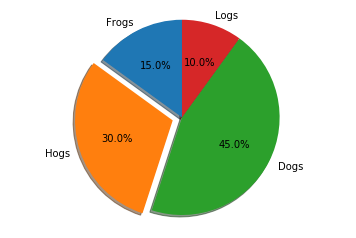

In [ ]:
import matplotlib.pyplot as plt

# 시계 반대 방향의 순서로 그린다.

labels = 'Frogs', 'Hogs', 'Dogs', 'Logs'
sizes = [15, 30, 45, 10]
explode = (0, 0.1, 0, 0)  # 두번째 파이를 바깥으로 돌출 시킨다.

fig1, ax1 = plt.subplots()
ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%',
        shadow=True, startangle=90)
ax1.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

plt.show()

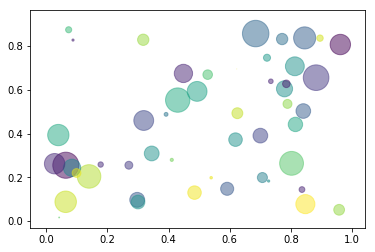

In [ ]:
"""
Simple demo of a scatter plot.
"""
import numpy as np
import matplotlib.pyplot as plt


N = 50
x = np.random.rand(N)
y = np.random.rand(N)
colors = np.random.rand(N)
area = np.pi * (15 * np.random.rand(N))**2  # 0 to 15 point radii

plt.scatter(x, y, s=area, c=colors, alpha=0.5)
plt.show()

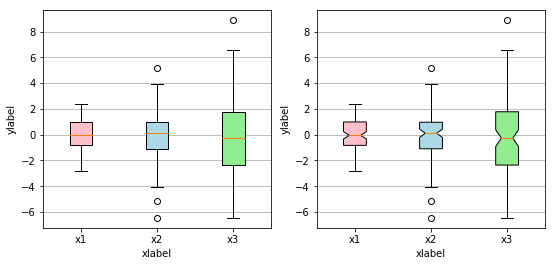

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Random test data
np.random.seed(123)
all_data = [np.random.normal(0, std, 100) for std in range(1, 4)]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))

# rectangular box plot
bplot1 = axes[0].boxplot(all_data,
                         vert=True,   # vertical box aligmnent
                         patch_artist=True)   # fill with color

# notch shape box plot
bplot2 = axes[1].boxplot(all_data,
                         notch=True,  # notch shape
                         vert=True,   # vertical box aligmnent
                         patch_artist=True)   # fill with color

# fill with colors
colors = ['pink', 'lightblue', 'lightgreen']
for bplot in (bplot1, bplot2):
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

# adding horizontal grid lines
for ax in axes:
    ax.yaxis.grid(True)
    ax.set_xticks([y+1 for y in range(len(all_data))], )
    ax.set_xlabel('xlabel')
    ax.set_ylabel('ylabel')

# add x-tick labels
plt.setp(axes, xticks=[y+1 for y in range(len(all_data))],
         xticklabels=['x1', 'x2', 'x3', 'x4'])

plt.show()


### <font color='blue'> <div style="text-align: center">End of Chapter </font>  